# Containerize a model service and verify its boundary

CPU companion; no accelerator is required. TPU execution not validated.

- Separate training from inference
- Understand the build context
- Keep runtime inputs explicit
- Prove the same request survives the boundary

Your model works in a notebook, but another machine has a different interpreter, library set and working directory. Let’s export a small prediction artifact, verify it in a fresh process, then run the same boundary in a real Docker container.

## The idea

Containerization packages a runtime environment; a running container executes a process; a model artifact supplies versioned numerical content. Keeping these identities separate makes deployment and debugging reproducible.

## An image, a process and an artifact have different identities

A container image can start successfully while loading the wrong model path or configuration. Conversely, a valid model artifact can fail because the runtime lacks a compatible dependency. Record the image identity and model/configuration identities together.

Trace the build context into the image, then configuration and artifact mounts into the running process. Mark the request boundary where decoding, validation, inference and response encoding happen. A readiness signal should reflect the actual service contract, not merely process existence.

The current subprocess experiment demonstrates a process boundary. It is not evidence that a Docker build or container benchmark ran. Use that distinction when extending the lesson to your own container execution and keep the resulting receipt.

### Pause and reason

Does pinning a container image automatically pin a model loaded from a mutable path?

<details><summary>Compare your reasoning</summary>

No. The external artifact can change independently. Pin and verify its identity as part of the release configuration.

</details>

## Separate training from inference

Our service evaluates an exported scalar affine model using the Python standard library. The connected lab actually trains that model in JAX first. Inference does not need the optimizer, training data or MLflow server. This small portable contract makes it possible to compare Python-process, MLflow pyfunc and container outputs independently. Larger JAX exports need a compatible runtime and their own serialization checks; copying two coefficients does not demonstrate arbitrary graph portability.

## Understand the build context

Docker only sees the build context sent to the engine. The supplied .dockerignore excludes everything except Dockerfile and service.py, so local data, notebooks, environment files and training artifacts do not enter the image accidentally. COPY names only the service source. The base image is pinned by its observed digest, not just a moving tag. Pinning records an identity; you still need a deliberate dependency update process and image scanning.

## Keep runtime inputs explicit

MODEL_PATH selects a mounted artifact and MODEL_SHA256 verifies its bytes before serving. Configuration can be supplied at runtime; credentials belong in a runtime secret mechanism rather than build arguments or image layers. The container runs as a numeric non-root user, with a read-only filesystem and model mount. The default network-free check needs no published port. The optional HTTP mode binds a service port, enforces a small request-body and batch limit, and exposes readiness. It is a teaching server, not a production concurrency stack.

## Prove the same request survives the boundary

The CPU companion writes an artifact and starts a fresh Python process for every request. Singleton and changed-size batches must match independent arithmetic. An empty batch, boolean input and changed artifact digest are rejected. These are process checks; the connected Docker checker additionally builds the actual image, mounts the artifact, checks non-root execution, performs inference and tests readiness inside the running container. Keep those two evidence scopes distinct.

**Train and retain the model first**

```bash
python projects/engineering-release/mlflow_lab.py --output ./engineering-run
```

**Expected:** Creates model.json and report.json using actual tracked training.

**Build the local teaching image**

```bash
docker build -t jaxpathways-engineering:course projects/engineering-release
```

**Expected:** Build succeeds from the pinned base digest and copies only the inference service.

**Run the container qualification lab**

```bash
python projects/engineering-release/container_check.py --model ./engineering-run/model.json --output ./container-report.json
```

**Expected:** Checks actual container predictions, digest rejection, non-root identity and HTTP readiness. Requires a running local Docker engine.

## Readiness, liveness and startup are different

A process can be alive while its model failed to load. Readiness should require a verified model and a completed smoke prediction; liveness asks whether the service is stuck. Docker HEALTHCHECK reports health but does not itself implement a rollout controller or restart policy. A Kubernetes startup probe can protect a slow load, readiness can remove an instance from service traffic, and liveness may restart it. Benchmark cold startup separately from warmed inference, then add concurrency and overload limits.

## Ship the artifact you actually checked

CI should run tests, build once, record the resulting image identity, verify the model and request contract, and attach evaluation evidence. Promote that immutable bundle into staging before selecting production. Rebuilding from a tag at deployment time can change the environment after testing. On accelerators, also verify drivers, runtime libraries, device discovery and kernel support. This CPU container receipt is not GPU or edge qualification.

## Run the example

In [1]:
import hashlib, json, os, subprocess, sys, tempfile
from pathlib import Path
MODEL = {'schema': 1, 'weight': 2., 'bias': 1.}
# The deployment contract uses exported coefficients, not a training environment.
SERVICE = '''import hashlib,json,math,os,sys
raw=open(os.environ['MODEL_PATH'],'rb').read()
if hashlib.sha256(raw).hexdigest()!=os.environ['MODEL_SHA256']: raise ValueError('artifact mismatch')
m=json.loads(raw)
x=json.load(sys.stdin)['inputs']
if not isinstance(x,list) or not 1<=len(x)<=32: raise ValueError('batch limit')
if any(type(v) not in (int,float) or not math.isfinite(v) for v in x): raise ValueError('invalid input')
print(json.dumps({'predictions':[m['weight']*v+m['bias'] for v in x]},allow_nan=False))
'''
accepted, rejected = 0, 0
with tempfile.TemporaryDirectory(prefix='container-contract-') as folder:
    root = Path(folder); artifact = root / 'model.json'; service = root / 'service.py'
    artifact.write_text(json.dumps(MODEL, sort_keys=True)); service.write_text(SERVICE)
    sha = hashlib.sha256(artifact.read_bytes()).hexdigest()
    env = dict(os.environ, MODEL_PATH=str(artifact), MODEL_SHA256=sha)
    for values in [[-.5], [-2., 0., 1.5]]:
        completed = subprocess.run([sys.executable, str(service)], input=json.dumps({'inputs': values}), text=True, capture_output=True, env=env, check=True)
        actual = json.loads(completed.stdout)['predictions']
        assert actual == [2 * value + 1 for value in values]
        accepted += 1
    for payload, changes in [({'inputs': []}, {}), ({'inputs': [True]}, {}), ({'inputs': [0.]}, {'MODEL_SHA256': '0' * 64})]:
        completed = subprocess.run([sys.executable, str(service)], input=json.dumps(payload), text=True, capture_output=True, env=dict(env, **changes))
        assert completed.returncode != 0; rejected += 1
print('Fresh-process valid requests:', accepted, 'rejected boundaries:', rejected)
print('This companion tests the process/artifact contract. Run the Docker lab for container evidence.')


Fresh-process valid requests: 2 rejected boundaries: 3
This companion tests the process/artifact contract. Run the Docker lab for container evidence.


Expected: Fresh-process valid requests: 2 rejected boundaries: 3
This companion tests the process/artifact contract. Run the Docker lab for container evidence.

## Observe the process boundary before containerizing it

Predict: Should invalid requests produce a prediction or a failed process?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [2]:
visual_data={'kind':'bar','labels':['valid predictions','expected rejections'],'xlabel':'local process contract','ylabel':'observed case count','series':[{'label':'executed CPU cases','y':[accepted,rejected]}]}

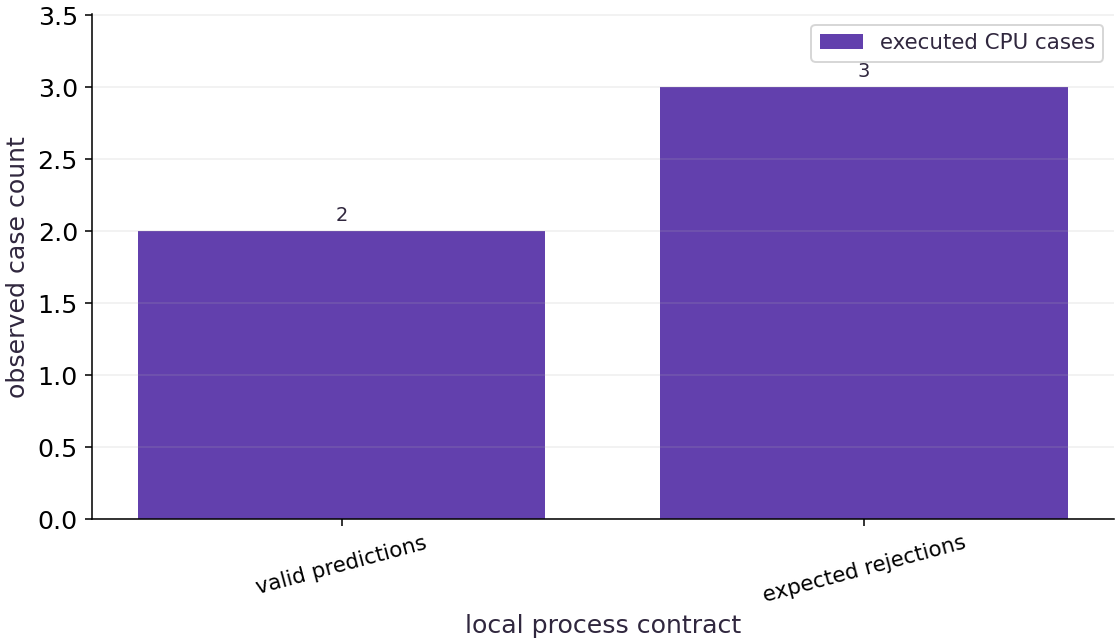

In [3]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal categories separate the two valid request shapes from three deliberately invalid boundaries. Bar height is the number of cases observed by the local subprocess checker: $2$ successful prediction cases and $3$ expected rejections. These counts do not represent throughput, latency or a failure probability. Each success is also checked against independent affine arithmetic.

### Connect it to the computation

A container must preserve this contract. The Docker lab supplies additional engine, user and readiness evidence; this plot comes from ordinary Python processes and cannot prove image behavior by itself.

## Change the batch without changing the model

Predict: Will a three-element request give the same values as three singleton requests?

In [4]:
batch=[-.25,.75,2.]
assert [MODEL['weight']*x+MODEL['bias'] for x in batch]==[.5,2.5,5.]
print('Independent three-input predictions: 0.5, 2.5, 5.0')

Independent three-input predictions: 0.5, 2.5, 5.0


Expected: Independent predictions are 0.5, 2.5 and 5.0.

Batching changes transport shape, not the per-observation prediction contract. A stateful or preprocessing-dependent service needs additional checks.

## Your exercise

Reject an artifact whose bytes changed after its expected digest was recorded.

In [5]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [6]:
original=json.dumps(MODEL,sort_keys=True).encode()
mutated=json.dumps(dict(MODEL,bias=2.),sort_keys=True).encode()
assert hashlib.sha256(original).hexdigest()!=hashlib.sha256(mutated).hexdigest()
print('Changed artifact requires a new recorded digest.')

Changed artifact requires a new recorded digest.


## Reject a nonfinite request · transfer

Send an infinite input to the process contract and verify the rejection.

Hint: The validation boundary should reject before producing JSON predictions.

In [7]:
# Write your attempt here.

## Reference reasoning

A request can parse as JSON in Python while still violating the numerical service contract.

In [8]:
with tempfile.TemporaryDirectory() as tmp:
    p=Path(tmp);(p/'model').write_text(json.dumps(MODEL));(p/'service.py').write_text(SERVICE)
    env=dict(os.environ,MODEL_PATH=str(p/'model'),MODEL_SHA256=hashlib.sha256((p/'model').read_bytes()).hexdigest())
    bad=subprocess.run([sys.executable,str(p/'service.py')],input=json.dumps({'inputs':[float('inf')]}),text=True,capture_output=True,env=env)
    assert bad.returncode != 0
print('Nonfinite input rejected before output.')

Nonfinite input rejected before output.


## Checkpoint

The image built successfully. What should happen before serving traffic?

1. Assume the trained model is included and ready.
2. Load the expected artifact, verify its digest and complete a prediction through the target runtime.
3. Ignore preprocessing because dependencies are pinned.

## Diagnose

A missing model mount is a runtime configuration error, not a reason to rebuild the model into every image. Permission errors call for mount/user inspection. A successful local process check does not prove Docker is running. Keep engine and target failures in their own receipt.

## Evidence

Keep the artifact digest, valid and rejected requests, fresh-process output and, when Docker is available, the actual image identity, runtime user and container qualification receipt.

## Carry forward

- Separate training from inference
- Prove the same request survives the boundary
- Ship the artifact you actually checked

## Primary references

- [Docker build best practices](https://docs.docker.com/build/building/best-practices/)
- [Dockerfile reference and health checks](https://docs.docker.com/reference/dockerfile/)
- [Kubernetes liveness, readiness and startup probes](https://kubernetes.io/docs/concepts/configuration/liveness-readiness-startup-probes/)